# **Deliverable 3: Ultrasound Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 19–24** (Weeks 8–9) of the course. You will explore the complete physics foundation underlying modern ultrasound imaging systems, from fundamental acoustic wave behavior through to clinical image formation and artifact management. Your work will integrate theoretical understanding with computational simulations and experimental design problems.

### Learning Outcomes:

Upon successful completion, you will be able to:
1. **Analyze** acoustic propagation through multi-layer tissue models to predict imaging penetration
2. **Design** ultrasound transducer systems with optimized beam characteristics for specific clinical applications
3. **Implement** ultrasound image reconstruction algorithms from simulated echo data
4. **Evaluate** Doppler measurement feasibility for given tissue depths and velocity ranges
5. **Identify and mitigate** artifacts in ultrasound images through understanding of physics mechanisms
6. **Compare and select** ultrasound imaging modes and parameters for clinical scenarios


---

# Part 1: Acoustic Physics & Tissue Interactions

## Key Concepts

**Impedance & Reflection:** Determines how much sound bounces at tissue boundaries
- Z = ρc (impedance in MRayl) — larger impedance mismatch → stronger reflection
- R = (Z₂ − Z₁)/(Z₂ + Z₁) (pressure reflection coefficient)
- R_I = R² (intensity reflection) — fraction of acoustic energy reflected
- T_I = 4Z₁Z₂/(Z₁+Z₂)² (intensity transmission) — fraction that passes through

**Attenuation:** Signal loss as sound travels through tissue due to absorption and scattering
- Loss = α · frequency · distance (higher frequency attenuates faster)
- α ≈ 0.5–0.8 dB/(cm·MHz) in soft tissue
- Round-trip loss: multiply distance by 2 (sound goes down and back up)
- Total loss in dB = 20·log₁₀(transmitted amplitude / received amplitude)

**Wavelength & Frequency:** Trade-off between resolution and penetration
- λ = c / f (c = 1540 m/s in soft tissue)
- Higher frequency f: shorter wavelength → better resolution but greater attenuation → shallower penetration
- Lower frequency f: longer wavelength → worse resolution but less attenuation → better penetration

## 1.1 Acoustic Impedance & Reflection Analysis

Acoustic impedance, Z = ρc, is the fundamental property determining how sound reflects at tissue boundaries. Ultrasound images are primarily formed from echoes at impedance boundaries.

### **Questions 1**
You are designing an ultrasound probe for cardiac imaging. The probe needs good acoustic coupling between the transducer (Z ≈ 25 MRayl) and skin (Z ≈ 1.54 MRayl). 
- a) Calculate the pressure reflection coefficient at the transducer-skin interface **without coupling gel**. What percentage of energy is lost to reflection (intensity)?

    The reflection coefficient is calculated:

    $$ R = (\frac{Z_2 - Z_1}{Z_2 + Z_1})^2 = (\frac{1.54 \text{ MRayl} - 25 \text{ MRayl}}{1.54 \text{ MRayl} + 25 \text{ MRayl}})^2 = 78\% $$

    78% of the incident intensity is lost.

- b) Explain why coupling gel (Z ≈ 1.5 MRayl) improves transmission. Calculate the improvement in transmitted intensity.

    Coupling gel has a similar acoustic impedance to skin, so nearly all of the sound waves travelling through the gel will be transmitted into the human body.

    Calculating the new reflection coefficient:

    $$ R = (\frac{Z_2 - Z_1}{Z_2 + Z_1})^2 = (\frac{1.54 \text{ MRayl} - 1.5 \text{ MRayl}}{1.54 \text{ MRayl} + 1.5 \text{ MRayl}})^2 = 0.017\% $$

    This represents an improvement in transmitted intensity of $\frac{100\% - 0.017\%}{100\% - 78\%} = 4.57$ times.

    Note, however, that matching layers will still be required between the transducer and the coupling gel; otherwise, a significant amount of the original vibrations from the transducer will still be lost.

- c) Why must matching layers be exactly λ/4 thick to optimally reduce reflections? (Hint: Consider wave interference.)

    A matching layer thickness of λ/4 means that the reflection boundary occurs at the peak of the wave; since sound waves change phase by 180° when they are reflected from a boundary with a lower-impedance region, this means that the peak of the wave will become a trough, and thus will destructively interfere with the incident wave. Thus, the intensity of reflections will be even further reduced to near-zero.


### **Questions 2**
In abdominal imaging, you encounter three successive tissue boundaries:
1. Skin (ρ = 1100 kg/m³, c = 1700 m/s) → Fat (ρ = 900 kg/m³, c = 1450 m/s)
2. Fat → Muscle (ρ = 1050 kg/m³, c = 1580 m/s)
3. Muscle → Bone cortical (ρ = 1850 kg/m³, c = 3500 m/s)

- a) Calculate Z for each tissue

    The acoustic impedance for a given material is calculated $Z = \rho c$. For each of the tissues:
    - Skin: $Z = \rho c = 1100 \text{ kg/m³} \times 1700 \text{ m/s} = 1.87 \text{ MRayl}$
    - Fat: $Z = \rho c = 900 \text{ kg/m³} \times 1450 \text{ m/s} = 1.305 \text{ MRayl}$
    - Muscle: $Z = \rho c = 1050 \text{ kg/m³} \times 1580 \text{ m/s} = 1.659 \text{ MRayl}$
    - Cortical bone: $Z = \rho c = 1850 \text{ kg/m³} \times 3500 \text{ m/s} = 6.475 \text{ MRayl}$

- b) Calculate reflection coefficients at each boundary

    At each boundary:

    $$ R = (\frac{Z_2 - Z_1}{Z_2 + Z_1})^2$$

    Skin-to-Fat:

    $$ R = (\frac{1.305 \text{ MRayl} - 1.87 \text{ MRayl}}{1.305 \text{ MRayl} + 1.87 \text{ MRayl}})^2 = 3.17\% $$

    Fat-to-Muscle:

    $$ R = (\frac{1.659 \text{ MRayl} - 1.305 \text{ MRayl}}{1.659 \text{ MRayl} + 1.305 \text{ MRayl}})^2 = 1.43\% $$

    Muscle-to-Cortical-Bone:

    $$ R = (\frac{6.475 \text{ MRayl} - 1.659 \text{ MRayl}}{6.475 \text{ MRayl} + 1.659 \text{ MRayl}})^2 = 35.0\% $$

- c) Rank the boundaries by reflection strength. Which is most problematic for imaging?

    In order of decreasing reflection strength, the boundaries are muscle/cortical bone, fat/muscle, and skin/fat. Of these, the muscle/cortical bone boundary has significantly more reflection than the other boundaries, and so is the most problematic for imaging.

- d) Why are cortical bone landmarks often clearly visible as "dark shadows" in ultrasound?

    Strong reflection at the muscle/cortical bone interface means that not as much of the transmitted intensity makes it to features behind the cortical bone (and similarly, reflections from features behind the cortical bone have significant reflection back away from the detector when they reach the cortical bone again); thus, while trying to percieve features at that depth, very little intensity will be perceived, producing the 'dark shadows'.

## 1.2 Multi-Layer Tissue Transmission Model

Ultrasound must penetrate through multiple tissue layers to reach target organs. Both reflection losses at each interface and attenuation within each tissue layer reduce the overall signal strength. This analysis predicts whether adequate signal will return for imaging.

### **Coding Exercise 1**

Implement a function to calculate total round-trip transmission through multiple tissue layers, accounting for:
1. **Interface losses:** Reflection loss at each boundary between different tissues
2. **Attenuation losses:** Frequency-dependent signal loss as sound propagates through each layer (round-trip)

Return the overall transmission loss in dB and identify the dominating loss mechanism(s).

In [3]:
import numpy as np

# TODO: Define tissue properties (impedance, attenuation coefficient, thickness)

class tissue:                                       
    def __init__(self, density, speed_of_sound, attenuation_coefficient=0.5):
        # Direct parameters                           # Soft tissue is generally 0.5 dB/cm at 1 MHz
        self.density = density # kg/m3
        self.speed = speed_of_sound # m/s
        self.attenuation = attenuation_coefficient # dB / (cm * MHz)
        
        # Indirect parameters
        self.impedance = density * speed_of_sound

# attenuation coefficients taken from Lecture 18 slides
skin = tissue(1100, 1700) # no provided attenuation coefficient, so use the default soft tissue assumption (0.5)
fat = tissue(900, 1450, 0.63)
muscle = tissue(1050, 1580, 1.3)
cortical_bone = tissue(1850, 3500, 5)

# TODO: Calculate reflection losses at each interface
def calculate_reflection_loss(layer_1, layer_2):
    reflection_coefficient = ((layer_2.impedance - layer_1.impedance) / (layer_2.impedance + layer_1.impedance)) ** 2
    return 10 * np.log10(1 - reflection_coefficient)

def calculate_roundtrip_transmission_losses(frequency_MHz, skin_thickness_cm, fat_thickness_cm, muscle_thickness_cm, bone_thickness_cm):
    
    # Reflection losses (each interface appears twice along the beam's round trip)
    reflection_loss = calculate_reflection_loss(skin, fat) * 2
    if muscle_thickness_cm > 0: 
        # simple model: there should always be some skin and fat, but not necessarily muscle and/or bone
        reflection_loss += calculate_reflection_loss(fat, muscle) * 2
        if bone_thickness_cm > 0:
            reflection_loss += calculate_reflection_loss(muscle, cortical_bone) * 2
    reflection_loss *= -1

    print(f"Reflection losses: {reflection_loss} dB")

# TODO: Calculate attenuation losses through each layer (round-trip)

    attenuation_loss = skin.attenuation * frequency_MHz * skin_thickness_cm * 2
    attenuation_loss += fat.attenuation * frequency_MHz * fat_thickness_cm * 2  
    attenuation_loss += muscle.attenuation * frequency_MHz * muscle_thickness_cm * 2  
    attenuation_loss += cortical_bone.attenuation * frequency_MHz * bone_thickness_cm * 2  

    print(f"Attenuation losses: {attenuation_loss} dB")

# TODO: Report total loss in dB and identify dominant mechanism

    total_loss = reflection_loss + attenuation_loss
    print(f"Total losses: {total_loss} dB")

    if (reflection_loss > attenuation_loss):
        print("Reflection losses dominate.")
    elif (attenuation_loss > reflection_loss):
        print("Attenuation losses dominate.")

    return

print("No bone:")
calculate_roundtrip_transmission_losses(1, 0.2, 0.5, 1, 0.0)
print()

print("0.01 cm bone:")
calculate_roundtrip_transmission_losses(1, 0.2, 0.5, 1, 0.01)

No bone:
Reflection losses: 0.4042971861037223 dB
Attenuation losses: 3.43 dB
Total losses: 3.8342971861037225 dB
Attenuation losses dominate.

0.01 cm bone:
Reflection losses: 4.153540906734222 dB
Attenuation losses: 3.5300000000000002 dB
Total losses: 7.683540906734223 dB
Reflection losses dominate.


## 1.3 Clinical Penetration Analysis

### **Questions 3**

You are choosing the operating frequency for obstetric ultrasound in a pregnant patient at different gestational ages.
- a) **First Trimester (up to 3 cm depth through maternal tissue):** Compare 10 MHz vs. 5 MHz
  - Calculate expected round-trip loss through skin (0.2 cm) + adipose (2 cm) at both frequencies
  - Which frequency is better and why?

  Losses from reflection at the interface are not dependent on frequency; only on the acoustic impedance of the material. Since skin and fat (adipose tissue) have very similar acoustic impedances, we can assume that reflection losses from the skin-fat interface are negligible and consider only the round-trip attenuation losses.

  The round-trip attenuation in dB from a material with attenuation coefficient $\alpha$ when transmitting to depth $d$ at frequency $f$ is:
  $$\text{dB} = 2 \alpha d f$$

  Using the value of $\alpha = 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}}$ from the Lecture 18 slides, we can find:

  $$\text{dB} = 2 \times 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}} \times 2.2 \text{cm} \times 5 \text{MHz} = 13.86 \text{dB}$$

  $$\text{dB} = 2 \times 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}} \times 2.2 \text{cm} \times 10 \text{MHz} = 27.72 \text{dB}$$

  Attenuation in dB shows a linear relationship with frequency, which translates to exponentially decreasing intensity with frequency. Thus, the percentage remaining of the original intensity in each case is:

  $$10^{-\frac{13.86}{10}} = 4.1 \%$$

  $$10^{-\frac{27.72}{10}} = 0.17 \%$$

  Thus, the 5 MHz signal attenuates significantly less than the 10 MHz signal, and will both be less affected by noise and have less need for amplification.

- b) **Third Trimester (6–8 cm depth):** Should you switch to a lower frequency? Estimate the penetration limit at 3.5 MHz (typical for this scenario).

  At 3.5 MHz, the attenuation loss in dB becomes:

  $$\text{dB} = 2 \times 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}} \times d \text{cm} \times 3.5 \text{MHz} = (4.41 \times d) \text{ dB}$$
  
  Converting this to intensity loss:

  $$10^{-\frac{4.41 \times d}{10}}$$

  It is estimated that the minimum dB value for recovery of the signal in ultrasound is roughly 60 dB of attenuation (representing an output intensity fraction of $10^{-6}$, or 0.0001%). We can thus calculate the penetration limit:  

  $$ (4.41 \times d) = 60 \text{dB} \therefore d = \frac{60 \text{dB}}{4.41} = 13.6 \text{cm}$$

  This value is greater than 8 cm, so this frequency should have acceptable attenuation. Making the same comparison for 5 MHz:

  $$ 2 \times 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}} \times d \text{cm} \times 5 \text{MHz} = 6.3 \times d = 60 \text{dB} \therefore d = \frac{60 \text{dB}}{6.3} = 9.52 \text{cm}$$

  This, too, is greater than 8 cm, so there is *no need to switch to the 3.5 MHz transducer*, assuming that our output electronics can give us an accceptable signal at 60 dB. 


### **Questions 4**

Abdominal imaging in an obese patient requires imaging through 5 cm of additional adipose tissue. Assuming a 2–5 MHz transducer:
- a) How much additional loss (in dB) occurs due to the extra fat layer?

    Since losses in dB are additive in nature, we can calculate only the attenuation due to 5 cm of fat to identify the additional losses. 

    $$\text{dB} = 2 \times 0.63 \frac{\text{dB}}{\text{cm} \cdot \text{MHz}} \times 5 \text{cm} \times 5 \text{MHz} = 31.5 \text{dB}$$

- b) What compensatory adjustments to transducer power might be necessary?

    Transducer power is exactly proportional to intensity, since the latter is measured in watts per square meter. Thus, if we amplify the input transducer signal by 31.5 dB, the signal image should have the same output intensity as the original transducer power.

    Note, however, that this is not always possible, as attenuation produces heat, and this could be (in large amounts) dangerous to the patient. Thus, we must be careful to amplify the transducer power only to a safe level, and count on our readout electronics to do the rest of the amplification after the fact.

- c) Why might harmonic imaging be attractive here despite resolution trade-offs?

    If we detect only harmonics (e.g. the second harmonic) from the incident beam, we can improve the lateral resolution in the image by reducing near-field artifacts, such as those produced in fat layers close to the skin. This occurs because harmonics gradually build up with propagation distance due to rarefaction and compression, and so layers close to the skin will not affect the image as much as layers far from the skin.

---

# Part 2: Transducers & Beam Forming

## Key Concepts
**Wavelength & Element Spacing:** Fundamental limitation for phased arrays
- λ = c / f (c = 1540 m/s)
- Element spacing s ≤ λ/2 — prevents unwanted secondary lobes (grating lobes)

**Beam Geometry:** How the acoustic beam spreads and focuses
- Near-field length: N = D²/(4λ) where D = aperture diameter — distance from transducer to focal point
- Far-field divergence angle: θ ≈ λ/D (radians) — beam spreads beyond focal point
- Lateral resolution at focal depth: ≈ λ·z/D (z = focal depth) — tightest beam at focal point

**Axial Resolution:** Along the beam direction, determined by pulse length
- δz = (c · τ) / 2 where τ = pulse duration — shorter pulses give better resolution
- Trade-off: shorter pulses require wider bandwidth, which reduces signal-to-noise ratio

**Focal Zone:** Where beam is narrowest and lateral resolution is best
- Lateral resolution is excellent at focal depth, degrades in near field and far field
- Multiple focal zones (electronic or mechanical) improve coverage but reduce frame rate

## 2.1 Transducer Design & Near-Field Analysis

### **Questions 5**

You are designing a linear array transducer for abdominal imaging. Frequency: 5 MHz, Desired penetration: 15 cm, Focal zone: ~4 cm
- a) Calculate the wavelength in soft tissue at 5 MHz (c = 1540 m/s)

    $c = \lambda f$, therefore to calculate the wavelength:
    $$ \lambda = \frac{c}{f} = \frac{1540 \text{ m/s}}{5 \text{ MHz}} = 0.000308 \text{ m} = 308 \text{ }\mu\text{m}$$


- b) What is the minimum element spacing to avoid grating lobes (phased array constraint)?

    To prevent grating lobes, the element spacing $s$ must be less than or equal to than half the wavelength; in other words:

    $$ s \leq \frac{\lambda}{2} \therefore s \leq 154 \text{ }\mu\text{m}$$

    Thus, the maximum element spacing is 154 μm. The minimum element spacing, however, is limited by the physical bulk of the transducer size and thus will vary with technology (i.e. there is no theoretical minimum).

- c) To achieve 4 cm focal zone, what aperture diameter (number of active elements) is required? (Hint: N = D²/(4λ))

    For the near-field length to be at 4 cm (the focal depth), $4\text{ cm} = \frac{D^2}{4\lambda}$. Rearranging gives us:

    $$D = \sqrt{4N\times\lambda} = \sqrt{4\times4\text{ cm}\times308 \text{ }\mu\text{m}}= 0.7\text{ cm}$$

    Thus, the effective aperture diameter must be 0.7 cm. Assuming the piezoelectric elements are at their maximum element spacing of 154 μm, we can find the number of aperture elements:

    $$\frac{0.7 cm}{154 \text{ }\mu\text{m}} = 45.5$$

    Thus, 46 elements at maximal spacing (with 45 equal spaces between them) can be used to achieve this focal zone.

- d) Compare a 64-element vs 128-element array: which has better lateral resolution and why?

    A 128-element array has twice the aperture diameter of a 64-element array, assuming the elements are the same physical size. Assuming that the transducers are placed with the maximum spacing between them, the 64-element array has an aperture of approximately $64 \times 154 \text{ }\mu\text{m} = 1\text{ cm}$, while the 128-element array has an aperture of approximately $128 \times 154 \text{ }\mu\text{m} = 2\text{ cm}$.

    Calculating the focal lengths of each array: 

    $$L = \frac{D^2}{4\lambda} = \frac{(1\text{ cm})^2}{4\times 308 \text{ }\mu\text{m}} = 8\text{ cm} $$
    $$L = \frac{D^2}{4\lambda} = \frac{(2\text{ cm})^2}{4\times 308 \text{ }\mu\text{m}} = 32\text{ cm} $$

    The maximum achievable lateral resolution occurs at the focal length, and is equal to $\lambda \times \frac{L}{D}$:

    $$L = 308 \text{ }\mu\text{m} \times \frac{8\text{ cm}}{1\text{ cm}} = 0.25\text{ cm}$$
    $$L = 308 \text{ }\mu\text{m} \times \frac{32\text{ cm}}{2\text{ cm}} = 0.50\text{ cm}$$

    Thus, we can see that the maximum lateral resolution of the 128-element array is better than that of the 64-element array.

    Note, however, that lateral resolution is a function of depth; thus there are some depths at which the 64-element array will achieve better lateral resolution.



### **Questions 6**

A 7.5 MHz transducer for cardiac imaging through intercostal spaces has a diameter of 12 mm.
- a) Calculate the near-field length

    The near-field length of this transducer is (assuming the average speed-of-sound value for soft tissue):
$$L = \frac{D^2f}{4c} = \frac{(12\text{ mm})^2 \times 7.5\text{ MHz}}{4 \times 1540\text{ m/s}} = 17.5\text{ cm}$$

- b) Calculate the far-field divergence angle

    The far-field divergence angle for this transducer is (again, assuming the average speed-of-sound value for soft tissue):
$$\theta \approx \frac{\lambda}{D} = \frac{c}{fD} = \frac{1540\text{ m/s}}{7.5\text{ MHz} \times 12\text{ cm}} = 0.0017\text{ rad} = 0.097 \degree$$


- c) Can this transducer achieve useful resolution at 10 cm depth (typical mitral valve location)? Why or why not?

    10 cm is less than the near-field length of the transducer (17.5 cm), so the mitral valve would be in the near field (or Fresnel zone) of the beam. We know that beam lateral resolution increases as we get closer to the focal point; thus this lateral resolution will not be as good as at the focal length. Even so, we can estimate that it will be sufficient to image the mitral valve, as the near-field beam is mostly parallel.

## 2.2 Electronic Beam Steering & Focusing

### **Coding Exercise 2**

Implement a phased array beam-forming simulator. Calculate the time delays required to:
1. **Focus the transmit beam** at a specified focal depth
2. **Steer the beam** to a specified angle
3. **Simulate receive beam forming** by applying delays to received signals

Visualize the resulting beam pattern and assess the impact of different arrays (64 vs 128 elements) and frequencies.

In [150]:
import matplotlib.pyplot as plt
import numpy as np

def simulate_beam_forming(frequency_MHz, num_array_elements, element_spacing_mm, steering_angle_deg=None, focusing_depth_mm=None):

# TODO: Calculate wavelength and set up array geometry
    soft_tissue_speed = 1540.0 # m/s
    soft_tissue_attenuation = 0.05 # dB / MHz * mm (not cm!)
    wavelength = 1000 * soft_tissue_speed / (frequency_MHz * 10**6)
        # wavelength measured in mm

    area = np.zeros((num_array_elements*2, num_array_elements*2)) # each pixel has a side length of element_spacing_mm
    element_locations = range(num_array_elements) + (num_array_elements * 1/2) * np.ones((1, num_array_elements))[0]
        # since both 64 and 128 are even, we can do this
    '''
    dist_list = []
    for element in element_locations:
        distance = np.zeros(area.shape)
        for (x, y), pixel in np.ndenumerate(area):
            r = np.sqrt((x - element)**2 + y**2)
            distance[x][y] = r
        dist_list.append(distance)
    plt.imshow(dist_list[6])
    '''

# TODO: Calculate transmit delays for focusing at specified depth

    if focusing_depth_mm is not None: 

        focusing_delays = []

        # to focus the beam, all wavefronts must arrive at the focal point at the same time
        # thus, r/c + delay = the same value for every array element

        # the first array element will be furthest, so it will give us the minimum delay
        # the central array element will be closest, so it will have maximum delay
        
        center_pixel_mm = element_locations[int(len(element_locations) / 2)]

        total_time = 0

        for i, element_location in enumerate(element_locations):

            r = np.sqrt((focusing_depth_mm)**2 + (center_pixel_mm - element_location)**2)
                # distance from array element to focusing point

            if i == 0:
                total_time = r/soft_tissue_speed
                    # assume 0 delay for the elements on the edge

            delay = total_time - r/soft_tissue_speed 

            # this is a time delay; we must convert it to a phase delay

            phase_delay = 2*np.pi*frequency_MHz*(10**6)*delay
            
            focusing_delays.append(phase_delay)

            
        #plt.plot(focusing_delays)


# TODO: Calculate transmit delays for beam steering at specified angle

    # Equation based on Analog Devices, "Phased Array Antenna Patterns — Part 1: Linear Array Beam Characteristics and Array Factor"
    # https://www.analog.com/en/resources/analog-dialogue/articles/phased-array-antenna-patterns-part1.html

    if steering_angle_deg is not None:

        def phase_difference_for_steering(theta, element_spacing_mm, wavelength_mm):
            # Beam steering: delays are linear for each element
            return 2.0 * np.pi * element_spacing_mm * np.sin(theta) / wavelength_mm

        steering_delays = []
        current_delay = 0
        for i in range(num_array_elements):
            steering_delays.append(current_delay)
            current_delay += phase_difference_for_steering(np.radians(steering_angle_deg), element_spacing_mm, wavelength)


# TODO: Simulate and visualize beam patterns

    # No delays
    for (x, y), pixel in np.ndenumerate(area):
        for i, element in enumerate(element_locations):
            r = np.sqrt((x - element)**2 + y**2) # r is measured in mm
            attenuation = np.exp(-2*soft_tissue_attenuation*frequency_MHz*r/10) # exponential attenuation
            area[x][y] += attenuation * np.sin(wavelength * r)
    
    # Beam focusing
    focusing_area = np.zeros(area.shape)
    for (x, y), pixel in np.ndenumerate(area):
        for i, element in enumerate(element_locations):
            delay = focusing_delays[i]
            r = np.sqrt((x - element)**2 + y**2) # r is measured in mm
            attenuation = np.exp(-2*soft_tissue_attenuation*frequency_MHz*r/10) # exponential attenuation
            focusing_area[x][y] += attenuation * np.sin(wavelength * r + delay)
    
    # Beam steering
    steering_area = np.zeros(area.shape)
    for (x, y), pixel in np.ndenumerate(area):
        for i, element in enumerate(element_locations):
            delay = steering_delays[i]
            r = np.sqrt((x - element)**2 + y**2) # r is measured in mm
            attenuation = np.exp(-2*soft_tissue_attenuation*frequency_MHz*r/10) # exponential attenuation
            steering_area[x][y] += attenuation * np.sin(wavelength * r + delay/6)
    

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
    ax1.imshow(area, extent=[0, element_spacing_mm*num_array_elements*2, 0, element_spacing_mm*num_array_elements*2])
    ax1.set_title("No Delay")
    ax2.imshow(focusing_area, extent=[0, element_spacing_mm*num_array_elements*2, 0, element_spacing_mm*num_array_elements*2])
    ax2.set_title(f"Beam Focusing ({focusing_depth_mm} mm)")
    ax3.imshow(steering_area, extent=[0, element_spacing_mm*num_array_elements*2, 0, element_spacing_mm*num_array_elements*2])
    ax3.set_title(f"Beam Steering ({steering_angle_deg} degrees)")

    fig.suptitle(f"{num_array_elements} Elements")


# TODO: Compare different array configurations (64 vs 128 elements)

element_spacing_mm = 0.4

#simulate_beam_forming(2, 32, element_spacing_mm, focusing_depth_mm=5, steering_angle_deg=30)
''' See below code cells for simulation. '''


' See below code cells for simulation. '

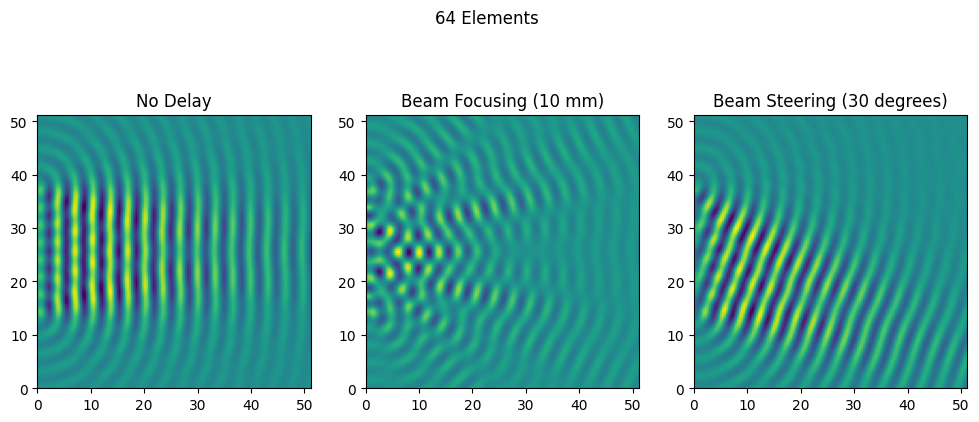

In [151]:
simulate_beam_forming(2, 64, element_spacing_mm, focusing_depth_mm=10, steering_angle_deg=30)

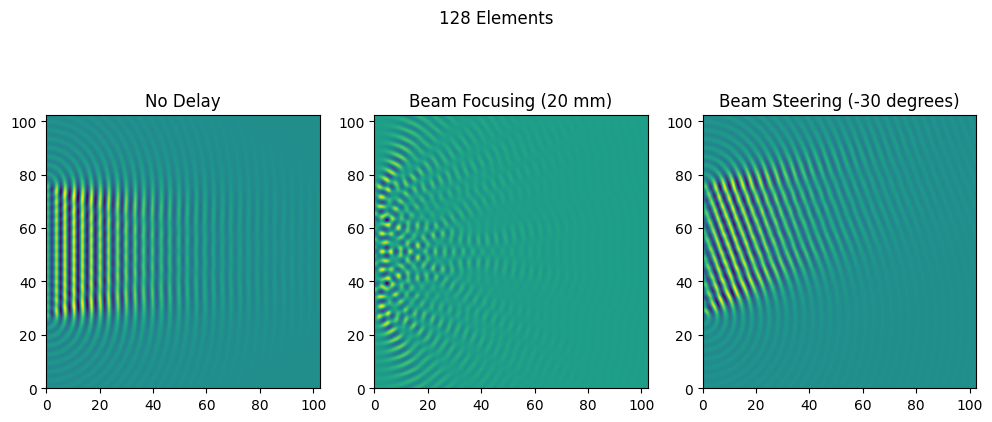

In [152]:
simulate_beam_forming(2, 128, element_spacing_mm, focusing_depth_mm=20, steering_angle_deg=-30)

## 2.3 Lateral Resolution Across Focal Zone

### **Questions 7**

A 5 MHz linear array with 128 elements and 0.4 mm spacing is used for abdominal imaging with an electronic focal depth of 6 cm.
- a) Calculate the lateral resolution at the focal depth

    The aperture diameter for this array is:
    $$D = 128 \times 0.4\text{ mm} = 5.12\text{ cm}$$

    The lateral resolution at the focal depth for this transducer is:
    $$ L = \lambda \times \frac{z}{D} = \frac{cz}{fD} = \frac{1540 \text{ m/s}}{5\text{ MHz}} \times \frac{6 \text{ cm}}{5.12\text{ cm}} = 361 \text{ } \mu \text{m}$$

- b) Calculate the lateral resolution at 1 cm (near field) and 15 cm (far field)

    Assuming that the equation $ L = \lambda\frac{z}{D}$ holds for a depth of $z$ in the far field,, the lateral resolution at 15 cm is:
    $$ L = \lambda \times \frac{z}{D} = \frac{cz}{fD} = \frac{1540 \text{ m/s}}{5\text{ MHz}} \times \frac{15 \text{ cm}}{5.12\text{ cm}} =  903\text{ } \mu \text{m}$$

    Since we know that the resolution is smallest (best) at the focal depth of 6 cm, we will use a modified form of this equation for the near field, where $z_0$ represents the focal depth.

    In essence, we wish to find the difference between $z_0$ and $z$, then subtract this from $z_0$ to allow for a linear increase (degradation) in lateral resolution as the depth decreases from the focal point, with the same slope as before. 

    $$ L = \lambda \times \frac{2z_0 - z}{D} = \frac{c(2z_0 - z)}{fD} = \frac{1540 \text{ m/s}}{5\text{ MHz}} \times \frac{(2\times 6\text{ cm}) - 1 \text{ cm}}{5.12\text{ cm}} =  903\text{ } \mu \text{m}$$


- c) Plot lateral resolution vs depth. At what depths does lateral resolution exceed (degrade beyond) 1 mm?

    See the below code block. Question d) has been moved after the code block.

Depth where Lateral Resolution = 1mm: 16.616616616616618
Lateral Resolution is greater than 1mm past this depth.


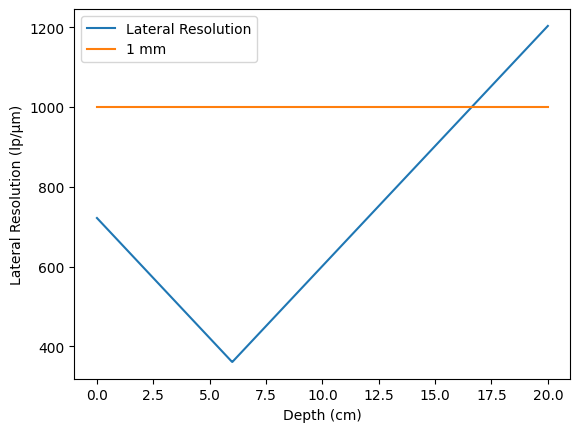

In [5]:
import matplotlib.pyplot as plt

depth = np.linspace(0, 20, 1000)
wavelength = 1540.0 / 5_000_000 # m
aperture = 5.12 # cm

focal_depth = 6

lateral_resolution = np.zeros(depth.shape)

# lateral resolution is lowest (best resolution) at the focal depth
# simple model: increase lateral resolution linearly on either side

for x, cm in np.ndenumerate(depth):
    if cm <= focal_depth: # near field
        # simple model: increase the lateral resolution linearly according to lambda * z / D
        lateral_resolution[x] = (2*focal_depth - cm) * wavelength  / aperture
    else: # far field
        # simple model: assume the lambda * z / D equation holds in far field
        lateral_resolution[x] = wavelength * cm / aperture
    if (abs(lateral_resolution[x] - 1/1000) < 0.0000005):
        print("Depth where Lateral Resolution = 1mm:", depth[x])
        print("Lateral Resolution is greater than 1mm past this depth.")

# convert m to um by multipying by 1000**2
plt.plot(depth, 1000*1000*lateral_resolution)
plt.plot(depth, 1000*1000*(1/1000) * np.ones(depth.shape))
plt.xlabel("Depth (cm)"); plt.ylabel("Lateral Resolution (lp/μm)")
plt.legend(["Lateral Resolution", "1 mm"])
plt.show()

- d) How could you improve lateral resolution at 15 cm depth? What are the trade-offs of each approach?

    There are a few ways to improve lateral resolution at 15 cm depth.
    * Beam focusing can be added to adjust the focal depth of the beam; however, the tradeoff of this method is that much more deviation and degradation of the lateral resolution may occur further from the new focal zone.
    * The sound wavelength can be decreased by increasing the frequency; however, the tradeoff of this method is increased attenuation through the patient's body.
    * Additional focal zones can be added electronically or mechanically; however, this necessitates increased scan time and thus decreased frame rate (e.g. in M-mode).

# Part 3: Image Formation & Reconstruction

---

## Key Concepts

**Time-Distance Relationship:** Converting echo timing to depth
- Depth = (c × time) / 2 where time is round-trip, c = 1540 m/s
- Every echo is displayed as a scan line, with brightness (intensity) encoded from the echo amplitude
- Axial resolution limited by pulse duration: δz = (c · τ) / 2 — can't resolve echoes closer than one pulse length apart

**Signal Processing Pipeline:** Sequential steps to convert raw RF data to viewable B-mode image
1. **Envelope Detection:** Extract amplitude envelope from RF signal — removes high-frequency carrier, keeps time-varying amplitude
2. **TGC (Time-Gain Compensation):** Multiply by gain increasing with depth to correct for attenuation losses
3. **Log Compression:** Convert to dB scale — compresses ~100 dB dynamic range to ~50 dB for display
4. **Scan Conversion:** Map from polar (angle, depth) to Cartesian (x, y) coordinates for rectangular display

**Frame Rate Constraint:** Speed at which images update on screen
- Time per scanline ≈ 2·(max depth)/c — limited by sound travel time
- Frame rate = 1 / (time per scan_line × num_scanlines)
- Adding multiple focal zones increases scanline time → reduces frame rate (trade-off for better image quality)

## 3.1 B-Mode Image Formation from Echo Data

### **Questions 8**
In a B-mode ultrasound image, three echoes are detected at times 50 μs, 80 μs, and 150 μs, with amplitudes 60 dB, 40 dB, and 25 dB respectively.
- a) Calculate the depths of the three reflectors (c = 1540 m/s)

    $$\frac{c \Delta t}{2} = \frac{1540\text{ ms} \times  50\text{ μs}}{2} = 3.85 \text{ cm}$$
    $$\frac{c \Delta t}{2} = \frac{1540\text{ ms} \times  80\text{ μs}}{2} = 6.16 \text{ cm}$$
    $$\frac{c \Delta t}{2} = \frac{1540\text{ ms} \times 150\text{ μs}}{2} = 11.55\text{ cm}$$

- b) If the transducer is operating at 5 MHz with a 2-cycle pulse length, what is the axial resolution?

    The spatial pulse length $SPL = n \lambda = n\frac{c}{f} = 2 \times \frac{1540 \text{ m/s}}{5 \text{ MHz}} = 616 \text{ μm}$. Thus, the spatial resolution
    $\Delta_a = \frac{SPL}{2} = \frac{616 \text{ μm}}{2} = 308 \text{ μm}$.

- c) Can the system resolve the first two echoes, or will they merge? Justify.

    Assuming that no aliasing occurs in either of the first two echoes, we can see that the difference between them is $6.16 - 3.85 = 2.31 \text{ cm}$, which is much greater than the spatial resolution of the system. Thus, the system will be able to resolve the two echoes.

- d) Explain why all three echoes must be displayed on a logarithmic (dB) scale rather than linear amplitude.

    Ultrasound waves attenuate exponentially when travelling through tissue, which means that echo intensities could be of vastly differing orders of magnitude. To make these intensity values more easily human-readable, they must be converted to a logarithmic scale, which effectively allows us to compare their orders of magnitude instead of their unmodified values.

### **Questions 9**
A linear array acquires 128 scan lines at 50 frames/second. Each scan line goes to 15 cm depth. 
- a) Calculate the time available per scan line for transmit + receive

    50 frames per second with 128 scan lines corresponds to a sampling period of $\frac{1}{50 \times 128} = 156$ microseconds per scan line.

- b) Is this sufficient for sound to travel to 15 cm and return? (Include time for multiple focal zones.)

    Assuming the typical speed of sound for soft tissue, the time for sound to travel 30 cm (15 cm to the target depth, and 15 cm back) with a single focal zone is $\frac{30 \text{ cm}}{1540 \text{ m/s}} = 195$ μs. This is more than the available time of 156 μs, so it will not be sufficient for this target depth. Adding more focal zones will increase the time required, which will even further make this system insufficient to image structures at a depth of 15 cm.

- c) If the system uses 2 focal zones instead of 1, how is frame rate affected?

    Using multiple focal zones increases the time required to acquire each scan line, which consequently decreases the frame rate of the system.

- d) What happens to temporal resolution (ability to detect motion) if you add a second focal zone?

    Because of the decreased frame rate, temporal resolution decreases as well, making it more difficult to detect motion. 

## 3.2 Ultrasound Image Reconstruction from Simulated Echo Data

### **Coding Exercise 3**

Implement a B-mode image reconstruction pipeline from simulated RF echo data:

1. **Create synthetic scattering phantom** using point scatterers
2. **Compute echo signals** for each beam direction
3. **Generate RF data** at transducer frequency
4. **Signal Processing:**
   - Envelope detection (analytic signal)
   - Time-gain compensation (TGC)
   - Log compression (dB scaling)
5. **Scan Conversion:** Map polar to Cartesian coordinates
6. **Display and analyze** reconstructed B-mode image

Reached coordinates (0, 0)


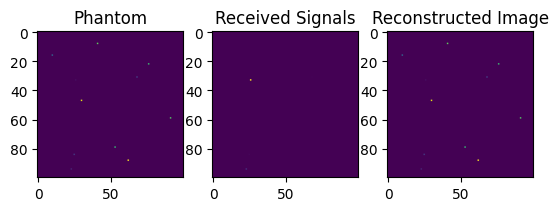

In [ ]:
import matplotlib.pyplot as plt
import random

#TODO: Coding Exercise 3 and 4 need to use proper B-mode imaging, rays from top of screen = waves... should make faster computation too.

# TODO: Create synthetic scattering phantom using point scatterers

grid = np.zeros((100, 100)) 
    # each cell in the grid represents the distance to the point in cm
    # if distance = 0, then I will treat it as infinite (no echo)

for i in range(random.randint(10, 30)):
    # generate some point scatterers at a random position with a random distance
    # distances may be between 0 cm and 9.9 cm
    # relative impedance may be between 0 and 1
    # at least 10 and up to 30 may be generated
    grid[random.randint(0, 99)][random.randint(0, 99)] = random.random()

# TODO: Simulate RF echo data for each scanline

# Simple model: the echo signal should be 
# a time-shifted version of the original pulse,
# attenuated by the soft tissue
def attenuate_signal(time_array, frequency_MHz, num_periods, time_delay, attenuation_dB):
    
    output = np.zeros(time_array.shape)

    attenuation = 10**(attenuation_dB/10) # convert from dB to multiplier

    for i, time in enumerate(time_array):
        if time > time_delay and time < (time_delay + num_periods/(frequency_MHz * 10**6)):
            output[i] += attenuation * np.sin(2*np.pi*(frequency_MHz * 10**6)*(time_array[i]+time_delay))
    
    # print(output)
    return output

def calculate_echo(time_array, frequency_MHz, num_periods, depth_cm):
    # average statistics for soft tissue
    c = 1540.0 # m/s 
    alpha = 0.5 # dB / (cm * MHz)

    delay = 2 * (depth_cm/100) / c # convert cm to m first

    attenuation = -2 * alpha * depth_cm * frequency_MHz # dB

    # print(delay, attenuation)

    return attenuate_signal(time_array, frequency_MHz, num_periods, delay, attenuation)


'''
original_signal = attenuate_signal(t, f, n, 0, 0)
plt.plot(t[0:500], original_signal[0:500])
time_delay = 10**-6 # seconds
plt.plot(t[0:500], attenuate_signal(t, f, 2, time_delay, -3)[0:500])
plt.plot(t[0:500], calculate_echo(t, f, 2, 20)[0:500])
plt.show()
'''
def reconstruction_pipeline(grid, end_time, num_samples):
    f = 7.5 # MHz
    n = 2

    timestep = end_time / num_samples
    time = np.linspace(0, end_time, num_samples)

    #echo_signals = np.zeros((grid.shape[0], grid.shape[1], t.size))
    signal_amplitudes = np.zeros((grid.shape))
    signal_times = np.zeros((grid.shape))

    for (x, y), dist in np.ndenumerate(grid):
        if (x % 100 == 0 and y % 100 == 0):
            print(f"Reached coordinates ({x}, {y})")
        if dist > 0:
            received_signal = calculate_echo(time, f, n, dist)

# TODO: Apply envelope detection to extract amplitude from RF signal
            signal_amplitudes[x][y] = max(received_signal)
            signal_times[x][y] = np.nonzero(received_signal)[0][0] * timestep
    
    received_amplitudes = signal_amplitudes.copy()

# TODO: Apply time-gain compensation (TGC)
    c = 1540.0 # m/s 
    alpha = 0.5 # dB / (cm * MHz)
    for (x, y), time in np.ndenumerate(signal_times):
        if time > 0:
            depth_cm = c * time / 2
            required_gain = 2 * alpha * depth_cm * f # dB

            signal_amplitudes[x][y] = signal_amplitudes[x][y] * 10**(required_gain/10)
            
# TODO: Apply log compression (dB scale)
            signal_amplitudes[x][y] = -10*np.log10(signal_amplitudes[x][y])

# TODO: Perform scan conversion (polar to Cartesian)
    # ...

# TODO: Display and analyze reconstructed B-mode image
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

    ax1.imshow(grid)
    ax1.set_title("Phantom")

    ax2.imshow(received_amplitudes)
    ax2.set_title("Received Signals")

    ax3.imshow(signal_amplitudes)
    ax3.set_title("Reconstructed Image")

    plt.show()

    return(signal_amplitudes)

reconstruction_pipeline(grid, 0.0003, 500000)

'''
As we can see, the linear-scaled received signals 
don't show the correct distances, and most signals are
nearly invisible due to exponential attenuation.

Meanwhile, the reconstructed image matches
the phantom nearly exactly by being able to
compensate for the attenuation losses with time
in soft tissue. 

Note that this reconstruction would likely be
affected in real life by deviations in the speed
of sound through different cells or tissues, and
so would show speckle or other nonidealities.
'''
pass

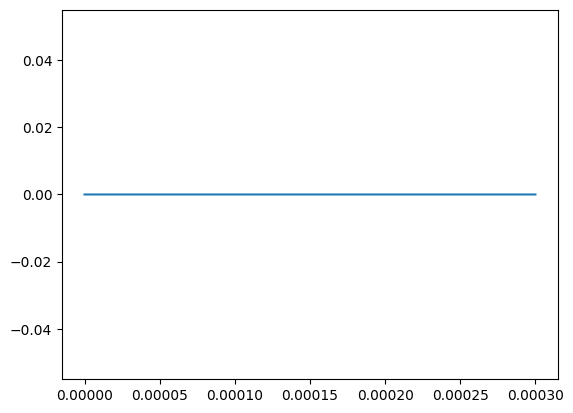

In [ ]:
# try a better version...

# TODO: Simulate RF echo data for each scanline

def better_pipeline(grid, end_time, num_samples):
    f = 7.5 # MHz
    n = 2

    timestep = end_time / num_samples
    t = np.linspace(0, end_time, num_samples)

    scanlines = []

    # Simple model: scanlines go from top to bottom (B-mode), linearly (not in polar form)
    for y, scanline in enumerate(np.transpose(grid)):
        echo = np.zeros(t.shape)
        reflections = []
        prev_impedance = 0
        for x, impedance in enumerate(scanline):
        # find reflection edges
            if impedance != prev_impedance:
                reflections.append([x, prev_impedance, impedance])
                echo += calculate_echo(t, f, n, x/10)
                # simple model: 100% reflection and 100% transmission


# TODO: Apply envelope detection to extract amplitude from RF signal
            # max(received_signal)
            # np.nonzero(received_signal)[0][0] * timestep

# TODO: Apply time-gain compensation (TGC)
 
# TODO: Apply log compression (dB scale)

# TODO: Perform scan conversion (polar to Cartesian)
    # ...

# TODO: Display and analyze reconstructed B-mode image
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)

    ax1.imshow(grid)
    ax1.set_title("Phantom")

    #ax2.imshow(received_amplitudes)
    ax2.set_title("Received Signals")

    #ax3.imshow(signal_amplitudes)
    ax3.set_title("Reconstructed Image")

    plt.show()

    #return(signal_amplitudes)

better_pipeline(grid, 0.0003, 500000)



## 3.3 Shepp-Logan Phantom Reconstruction

### **Coding Exercise 4**

Validate your B-mode reconstruction pipeline from **Coding Exercise 3** by applying it to a **Shepp-Logan digital phantom**. This simulates a more realistic imaging scenario with defined tissue-like features, allowing you to assess how well your algorithm handles anatomically-plausible structures compared to the simple synthetic scatterers in Exercise 3.

Reached coordinates (0, 0)
Reached coordinates (0, 100)
Reached coordinates (0, 200)
Reached coordinates (0, 300)
Reached coordinates (100, 0)
Reached coordinates (100, 100)
Reached coordinates (100, 200)
Reached coordinates (100, 300)
Reached coordinates (200, 0)
Reached coordinates (200, 100)
Reached coordinates (200, 200)
Reached coordinates (200, 300)
Reached coordinates (300, 0)
Reached coordinates (300, 100)
Reached coordinates (300, 200)
Reached coordinates (300, 300)


C:\Users\Nadee\AppData\Local\Temp\ipykernel_21752\3129075717.py:90: RuntimeWarning: divide by zero encountered in log10
  signal_amplitudes[x][y] = -10*np.log10(signal_amplitudes[x][y])


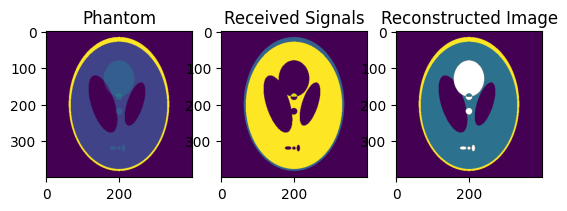

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# TODO: Load Shepp-Logan phantom
from skimage.data import shepp_logan_phantom
phantom = shepp_logan_phantom()

# TODO: Apply your reconstruction pipeline from Exercise 3 to this phantom
reconstruction_pipeline(phantom, 0.0001, 5000)

# TODO: Compare reconstructed image quality with ground truth
# ...

### **Analysis**

Compare reconstructed image with the ground truth phantom. Assess image quality and artifacts introduced by the ultrasound imaging process

## 3.4 Signal Processing & Dynamic Range

### **Questions 10**
Received RF echo signal ranges from -50 mV to +50 mV. After envelope detection and TGC, dynamic range is 0.1–100 mV (1000:1 or ~60 dB).
- a) Why does linear display (0–100 scale) make weak signals invisible?

    Because of the exponential nature of sound-wave attenuation, the vast majority of the received echoes will be close to zero on a linear scale. In particular, weak signals will be extremely close to zero, while strong signals will be relatively far from zero; however, 'weak' means strongly exponentially attenuated, a linear scale will have significant difficulty distinguishing both between different weak signals of different amplitudes and between 0.

- b) Apply log compression. What is the resulting dB range?
    $$10\log_{10}{\frac{100 \text { mV}}{0.1 \text { mV}}} = 30\text{ dB}$$
    $$10\log_{10}{\frac{0.1 \text { mV}}{0.1 \text { mV}}} =  0\text{ dB}$$

    The decibel range of this output signal is 30 dB.

- c) With 8-bit display (0–255 levels), how many dB per level? Sufficient for 3 dB myocardial contrast differences?

    There are $\frac{30}{256} = 0.117$ dB per level, so a 3 dB contrast difference would translate to a difference of 25 gray levels. Below, I have plotted pixels of brightness 0, 25, and 255 (since typical computer displays use 8 bits for colour display) to show that a difference of 25 gray levels is barely visible to an observer, and thus this display level is barely sufficient.

- d) How does 16-bit display depth improve visualization of subtle tissue differences?

    By increasing the display depth (bits per pixel), we can exponentially increase the number of dB per level, which corresponds to an exponential increase in intensity resolution. In practice, this requires adjusting the display window settings to allow the human eye to see the better resolution, but it allows for fine differences to be much more easily distinguished once this is done.

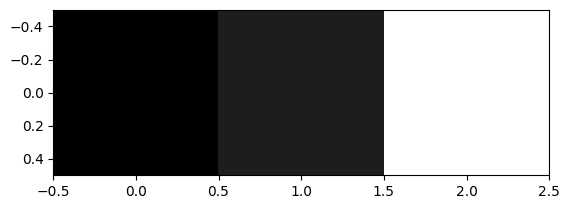

In [ ]:
x = [[0, 25, 255]]; plt.imshow(x, cmap='Greys_r'); plt.show()

# Part 4: Doppler Imaging & Artifact Analysis

---

## Key Concepts

**Doppler Shift:** Frequency change from moving targets (blood flow)
- Δf = 2f₀·v·cos(θ)/c — factor of 2 because sound travels to target and returns
- Only velocity component along beam (cos(θ)) contributes; perpendicular motion is invisible
- v_max = c·PRF / (4f₀·cos(θ)) [Nyquist limit for pulsed Doppler] — velocities above this exceed sampling rate
- Below Nyquist: velocity measured correctly; above Nyquist: aliasing occurs (velocity appears reversed)

**Artifacts:** Misinterpretation of ultrasound signal caused by physics assumptions
- **Shadowing:** Strong attenuator (bone, gas) blocks transmission → dark (anechoic) region directly behind
- **Enhancement:** Low-attenuation region (fluid-filled cyst) allows more signal → bright region directly behind  
- **Mirror Image:** Reflection off strong smooth surface (diaphragm, bone) creates false duplicate structure on opposite side
- **Reverberation:** Multiple bounces between two strong reflectors → equally-spaced ghost echoes
- **Speckle:** Inherent grainy texture from constructive/destructive interference of scattered signals — characteristic ultrasound appearance

## 4.1 Pulsed-Doppler Velocity Measurement

### **Questions 11**

A 5 MHz pulsed-Doppler system measures blood flow in the carotid artery.
- a) A red blood cell moving at 0.8 m/s toward the transducer causes a Doppler shift. Calculate shift frequency (assume 60° angle, c = 1540 m/s)

    $$\Delta f_D = \frac{2vf_0\cos\theta_D}{c} = \frac{2\times 0.8\text{ m/s} \times 5\text{ MHz} \times\cos(60\degree)}{1540\text{ m/s}} = 2597 \text{ Hz}$$

    The blood cell is moving towards the transducer, so the shift frequency is positive.

- b) System has PRF = 6 kHz. Calculate the Nyquist velocity limit.

$$v_{max} = \frac{PRF \times c}{4 \times f_0} = \frac{6\text{ kHz} \times 1540\text{ m/s}}{4 \times 5\text{ MHz}} = 0.462\text{ m/s}$$

- c) Can you measure 0.8 m/s without aliasing?

    0.8 m/s is greater than 0.462 m/s, so the Doppler shift from the red blood cell's movement will cause aliasing in the system.

- d) What PRF is needed to measure 1.5 m/s at 60° angle without aliasing?

    Rearranging the equation for maximum measurable velocity:
$$PRF = \frac{4f_0v_{max}}{c} =  \frac{4\times 5\text{ MHz} \times 1.5\text{ m/s}}{1540 \text{ m/s}} = 19.48\text{ kHz}$$

### **Questions 12**
In severe carotid stenosis, peak systolic velocity reaches 4 m/s.
- a) Can standard PW Doppler (PRF ~ 8 kHz, f = 5 MHz, θ = 60°) measure this without aliasing?

    The Doppler shift of this velocity is: 

    $$\Delta f_D = \frac{2vf_0\cos\theta_D}{c} = \frac{2\times 4\text{ m/s} \times 5\text{ MHz} \times\cos(60\degree)}{1540\text{ m/s}} = 13 \text{ kHz}$$

    No, this system cannot measure 4 m/s without aliasing; 13 kHz is greater than the Nyquist limit of half the PRF (4 kHz), so aliasing will occur.

- b) What is the maximum velocity this system can measure?

    $$v_{max} = \frac{PRF \times c}{4 \times f_0} = \frac{8\text{ kHz} \times 1540\text{ m/s}}{4 \times 5\text{ MHz}} = 0.616\text{ m/s}$$

- c) How would you modify the system for higher velocities? What are the trade-offs?

    To measure higher velocities, we can:

    * increase the Pulse Repetition Frequency, at the cost of decreasing the maximum depth of imaging (since $d_{max} \times v_{max} = \frac{c^2}{8f_0}$), or
    * decrease the transmit frequency $f_0$ of the imaging pulse, at the cost of lower lateral and axial resolution.


## 4.2 Artifact Identification & Mitigation

### **Coding Exercise 5**

**PART A:**
Load your reconstructed B-mode image from **Coding Exercise 3 or 4** and analyze what artifacts you actually see:

1. **Identify present artifacts:** Examine speckle patterns, reconstruction artifacts (ringing, aliasing), any other visual anomalies
2. **Characterize severity:** Describe the magnitude, spatial distribution, and impact on image quality
3. **Quantify where possible:** Calculate speckle statistics, measure artifact extent, assess signal-to-noise
4. **Visual documentation:** Display the image and annotate observed artifacts

**PART B:** Choose **one** artifact type that was NOT naturally present in your reconstructed image.

1. **Inject the artifact** synthetically onto your reconstructed imageFor your chosen artifact, create:
2. **Implement a detector** for that artifact type
3. **Test sensitivity:** Vary artifact parameters and measure detection performance
4. **Implement mitigation** to reduce the artifact
5. **Assess trade-offs:** Show what detail is preserved vs. what is lost

In [ ]:
# PART A: Analyze Natural Artifacts
# TODO: Load your reconstructed B-mode image from Exercise 3 or 4
# ...

# TODO: Identify and characterize artifacts present in your image
# ...

# TODO: Quantify artifact properties (speckle statistics, artifact extent, etc.)
# ...

# PART B: Inject Your Choice of Artifact
# TODO: Choose one artifact type (shadowing, enhancement, reverberation, or other)
# ...

# TODO: Synthetically inject the artifact onto your reconstructed image
# ...

# TODO: Implement a detector for your chosen artifact
# ...

# TODO: Test detector performance and implement mitigation
# ...


## 4.3 Clinical Artifact Case Studies

### **Questions 13**

You observe a dark (anechoic) structure within the gallbladder at 5 cm depth with a bright acoustic shadow extending below it.
- a) Is this definitely a gallstone? Explain the physical basis of the shadow.
    
    Acoustic shadowing occurs behind a highly reflective or attenuative structure; in this case, less acoustic radiation makes it to the shadowed area than would be predicted by the Time Gain Compensation due to the attenuation or reflection from the structure.
    For the case of a gallstone specifically, very high acoustic impedance within the gallstone is caused by the crystalline nature of the structure, so it is strongly reflective and thus causes an acoustic shadow behind it by reducing the amount of acoustic radiation that passes through it. Thus, we can say that this structure is definitely a gallstone.

- b) Could it be a polyp instead? What would distinguish them on ultrasound?
    
    Polyps are made of soft tissue and as such do not reflect acoustic radiation as easily. Thus, they do not display strong acoustic shadowing like a gallstone would. Thus, we can say that this structure is not a polyp.

### **Questions 14**

You observe a round, dark (anechoic) mass at 8 cm depth with a bright region immediately behind it.
- a) Is this definitely a cyst? Could it be a hypoechoic solid tumor instead?
    
    Solid tumours are made of soft tissue, which means that some speckle will be observed in the mass (due to backscatter) and there will be much less acoustic enhancement behind the structure. Cysts, meanwhile, are usually filled with fluid, which is anechoic due to lack of backscatter and will cause acoustic enhancement, such as that which is observed in this scenario. Thus, we can say that this is a cyst and not a tumour.
- b) Explain the physics of acoustic enhancement behind fluid-filled structures.
    
    Fluid-filled structures have very low acoustic attenuation because, unlike tissue, there are no small reflectors to cause backscatter of the signal. This means that upon passing through to the other side of the structure, the acoustic radiation has higher attenuation than predicted for a wave of the same frequency passing through soft tissue. This means that the Time Gain Compensation overcompensates for the signal attenuation and makes the region appear brigher than it should, producing the acoustic enhancement effect.

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable3.ipynb` and `.pdf`

**Due:** Monday, March 16, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Acoustic Physics & Tissue Interactions** | Q1 (a,b,c), Q2 (a,b,c,d), Coding Exercise 1, Q3 (a,b), Q4 (a,b,c) |
| **Part 2: Transducers & Beam Forming** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 2, Q7 (a,b,c,d) |
| **Part 3: Image Formation & Reconstruction** | Q8 (a,b,c,d), Q9 (a,b,c,d), Coding Exercise 3, Coding Exercise 4 + Analysis, Q10 (a,b,c,d) |
| **Part 4: Doppler Imaging & Artifact Analysis** | Q11 (a,b,c,d), Q12 (a,b,c), Coding Exercise 5, Q13 (a,b), Q14 (a,b) |
